# Drogued drifter in explicit wave orbital flow

We simulate the full drogued drifter ODE in a prescribed linear wave
field, using conditions representative of the southern Kiel Bight
(notebook 07): Hs ≈ 0.5m, Tp ≈ 3s, with a weak background current.

The buoy and drogue experience the instantaneous wave orbital velocities
at their respective positions and depths. We compare the resulting mean
drift against:
1. The Stokes drift prediction for a point particle at surface and drogue depth
2. The α-weighted steady-state estimate

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from drogued_drifters import DroguedDrifter

## Wave and current parameters

P95 conditions from notebook 07 (southern Kiel Bight):
- Surface Stokes P95 ~0.19 m/s → back out Hs from Stokes formula
- Tp ~4.2s (mean during strong events from earlier analysis)
- Eulerian current P95 ~0.23 m/s, nearly uniform in top 3m

In [2]:
# Wave parameters — P95 conditions
g = 9.81
Tp = 4.2          # peak period during strong events [s]
sigma = 2 * np.pi / Tp
k = sigma**2 / g
lam = 2 * np.pi / k
H_e = 1 / (2 * k)

# Back out Hs from target surface Stokes drift of ~0.19 m/s
# u_St(0) = A^2 * sigma * k, A = Hs/2
u_St_target = 0.19
A = np.sqrt(u_St_target / (sigma * k))
Hs = 2 * A

# Background Eulerian current (P95, uniform in depth)
U_mean = 0.23

# Stokes drift
u_St_0 = A**2 * sigma * k
u_St_3 = u_St_0 * np.exp(-2 * k * 3)

dd = DroguedDrifter()
alpha = np.sqrt(dd.k_b) / (np.sqrt(dd.k_b) + np.sqrt(dd.k_d))

print(f"Wave:    Hs={Hs:.2f}m, Tp={Tp}s, λ={lam:.1f}m, k={k:.3f}/m")
print(f"         e-folding depth: {H_e:.2f}m")
print(f"         pole/wavelength: {dd.l/lam:.2f}")
print(f"Stokes:  surface={u_St_0:.4f} m/s, 3m={u_St_3:.4f} m/s")
print(f"Current: U_mean={U_mean} m/s (uniform)")
print(f"Drifter: α={alpha:.4f}")

Wave:    Hs=1.49m, Tp=4.2s, λ=27.5m, k=0.228/m
         e-folding depth: 2.19m
         pole/wavelength: 0.11
Stokes:  surface=0.1900 m/s, 3m=0.0483 m/s
Current: U_mean=0.23 m/s (uniform)
Drifter: α=0.2182


## Define wave orbital velocity callback

The buoy at $(x_b, 0)$ and drogue at $(x_d, -z_d)$ each see
instantaneous linear wave orbital velocities plus the background current.
The drogue position depends on the pole angle, so $x_d$ and $z_d$ are
computed from $(x_b, \theta, \phi)$ inside the callback.

In [3]:
def wave_uv(*, t, z_d, y_b, x_b):
    """Instantaneous wave orbital velocity + background current.

    The DroguedDrifter passes z_d = -l*cos(theta), the actual drogue depth.
    x_b is the buoy x-position (used for wave phase at the buoy).
    The drogue x-position differs by l*sin(theta)*cos(phi), but the
    DroguedDrifter class doesn't pass x_d — we approximate x_d ≈ x_b
    (valid when the pole tilt is small relative to the wavelength).
    """
    # Wave orbital velocity: u = A*sigma*exp(kz)*cos(kx - sigma*t)
    # Buoy at z=0
    phase_b = k * x_b - sigma * t
    U_b = U_mean + A * sigma * np.cos(phase_b)
    V_b = 0.0

    # Drogue at z = -z_d (z_d is positive depth)
    phase_d = k * x_b - sigma * t  # same x approx
    U_d = U_mean + A * sigma * np.exp(-k * z_d) * np.cos(phase_d)
    V_d = 0.0

    return U_b, V_b, U_d, V_d

## Run the simulation

Integrate over 100 wave periods (~5 minutes). Compare against:
1. The full ODE driven by Stokes drift profile (steady shear, no orbital motion)
2. A surface point particle (Stokes + current)
3. A 3m-depth point particle

In [4]:
T_total = 100.0
n_periods = T_total / Tp
dt_out = Tp / 60
t_eval = np.arange(0, T_total, dt_out)

# Full ODE in explicit wave orbital flow
dd_wave = DroguedDrifter(get_uv=wave_uv)
ds = dd_wave.get_full_solution(t_span=(0, T_total), t_eval=t_eval, atol=1e-6, rtol=1e-6)

# Full ODE in steady Stokes drift profile
def stokes_uv(*, t, z_d, y_b, x_b):
    U_b = U_mean + u_St_0
    U_d = U_mean + u_St_0 * np.exp(-2 * k * z_d)
    return U_b, 0.0, U_d, 0.0

dd_stokes = DroguedDrifter(get_uv=stokes_uv)
ds_stokes = dd_stokes.get_full_solution(t_span=(0, T_total), t_eval=t_eval)

## Buoy trajectory and mean drift

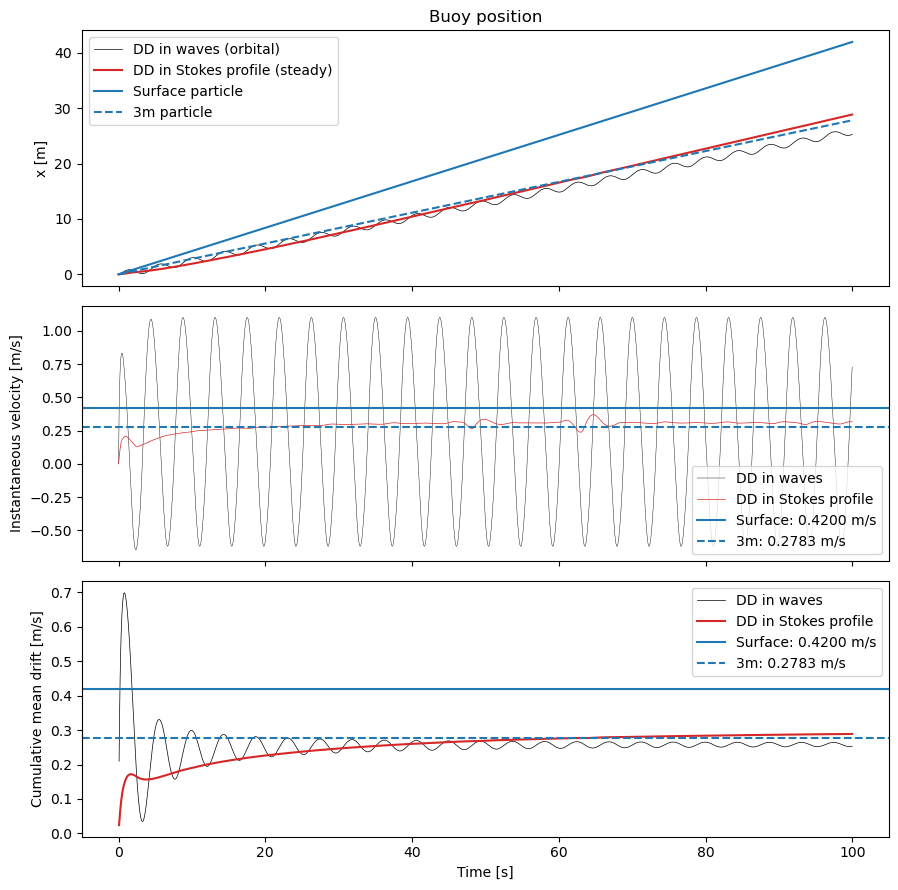

In [5]:
t = ds.time.values
x_wave = ds.x.values
x_stokes = ds_stokes.x.values

# Reference point-particle trajectories
x_surface = (U_mean + u_St_0) * t
x_3m = (U_mean + u_St_3) * t

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# Top: trajectories
ax1.plot(t, x_wave, "k", linewidth=0.5, label="DD in waves (orbital)")
ax1.plot(t, x_stokes, color="tab:red", linestyle="-", label="DD in Stokes profile (steady)")
ax1.plot(t, x_surface, color="tab:blue", linestyle="-", label="Surface particle")
ax1.plot(t, x_3m, color="tab:blue", linestyle="--", label="3m particle")
ax1.set_ylabel("x [m]")
ax1.legend()
ax1.set_title("Buoy position")

# Middle: instantaneous velocity
ax2.plot(t, ds.xd.values, "k", linewidth=0.3, label="DD in waves")
ax2.plot(t, ds_stokes.xd.values, color="tab:red", linewidth=0.5, label="DD in Stokes profile")
ax2.axhline(U_mean + u_St_0, color="tab:blue", linestyle="-", label=f"Surface: {U_mean + u_St_0:.4f} m/s")
ax2.axhline(U_mean + u_St_3, color="tab:blue", linestyle="--", label=f"3m: {U_mean + u_St_3:.4f} m/s")
ax2.set_ylabel("Instantaneous velocity [m/s]")
ax2.legend()

# Bottom: cumulative mean drift velocity = x(t)/t
t_nz = t[1:]
ax3.plot(t_nz, x_wave[1:] / t_nz, "k", linewidth=0.5, label="DD in waves")
ax3.plot(t_nz, x_stokes[1:] / t_nz, color="tab:red", label="DD in Stokes profile")
ax3.axhline(U_mean + u_St_0, color="tab:blue", linestyle="-", label=f"Surface: {U_mean + u_St_0:.4f} m/s")
ax3.axhline(U_mean + u_St_3, color="tab:blue", linestyle="--", label=f"3m: {U_mean + u_St_3:.4f} m/s")
ax3.set_ylabel("Cumulative mean drift [m/s]")
ax3.set_xlabel("Time [s]")
ax3.legend()

plt.tight_layout()
plt.show()

## Pole dynamics

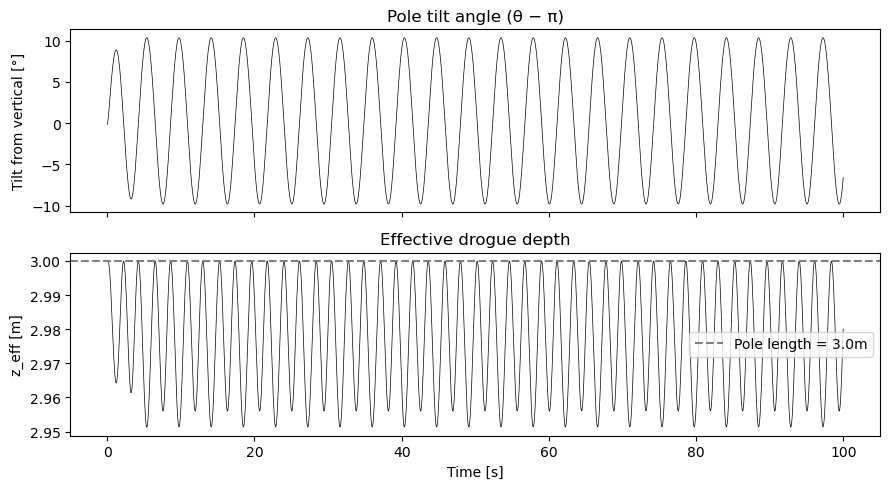

In [6]:
z_eff = -dd.l * np.cos(ds.theta.values)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

ax1.plot(t, np.degrees(ds.theta.values - np.pi), "k", linewidth=0.5)
ax1.set_ylabel("Tilt from vertical [°]")
ax1.set_title("Pole tilt angle (θ − π)")

ax2.plot(t, z_eff, "k", linewidth=0.5)
ax2.axhline(dd.l, color="tab:gray", linestyle="--", label=f"Pole length = {dd.l}m")
ax2.set_ylabel("z_eff [m]")
ax2.set_xlabel("Time [s]")
ax2.legend()
ax2.set_title("Effective drogue depth")

plt.tight_layout()
plt.show()

## Summary

In [7]:
# Mean drift from second half (skip transient)
t_last = t > T_total / 2

def mean_drift(x_arr):
    return (x_arr[t_last][-1] - x_arr[t_last][0]) / (t[t_last][-1] - t[t_last][0])

u_wave = mean_drift(x_wave)
u_stokes_dd = mean_drift(x_stokes)

print(f"Mean drift velocities (last {T_total/2:.0f}s):")
print(f"  DD in waves (orbital):     {u_wave:.5f} m/s")
print(f"  DD in Stokes profile:      {u_stokes_dd:.5f} m/s")
print(f"  Surface particle:          {U_mean + u_St_0:.5f} m/s")
print(f"  3m particle:               {U_mean + u_St_3:.5f} m/s")
print(f"  Waves − Stokes DD:         {(u_wave - u_stokes_dd)*1000:.2f} mm/s")

print(f"\nPole dynamics (in waves):")
theta_last = ds.theta.values[t_last]
tilt_deg = np.degrees(theta_last - np.pi)
print(f"  Mean tilt: {tilt_deg.mean():.2f}°")
print(f"  Tilt amplitude: {(tilt_deg.max() - tilt_deg.min())/2:.2f}°")
print(f"  Mean z_eff: {(-dd_wave.l * np.cos(theta_last)).mean():.3f}m")

print(f"\nPole dynamics (Stokes profile):")
theta_last_s = ds_stokes.theta.values[t_last]
tilt_deg_s = np.degrees(theta_last_s - np.pi)
print(f"  Mean tilt: {tilt_deg_s.mean():.2f}°")
print(f"  Mean z_eff: {(-dd_stokes.l * np.cos(theta_last_s)).mean():.3f}m")

Mean drift velocities (last 50s):
  DD in waves (orbital):     0.24378 m/s
  DD in Stokes profile:      0.30840 m/s
  Surface particle:          0.42000 m/s
  3m particle:               0.27834 m/s
  Waves − Stokes DD:         -64.62 mm/s

Pole dynamics (in waves):
  Mean tilt: 0.22°
  Tilt amplitude: 10.08°
  Mean z_eff: 2.977m

Pole dynamics (Stokes profile):
  Mean tilt: 0.49°
  Mean z_eff: 3.000m


## 3-component wave field from CMEMS partitioned parameters

Use the wind wave, primary swell, and secondary swell partitions from
the CMEMS Baltic wave model. Each has its own Hs, period, and direction,
giving a 3-component Stokes profile and wave orbital field.

/Users/wrath/src/github.com/geomar-od-lagrange/2025_drogued_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO - 2026-03-25T10:33:31Z - Selected dataset version: "202311"


INFO - 2026-03-25T10:33:31Z - Selected dataset part: "default"


Wind wave   : Hs=1.216m  T=3.5s  dir=295°  u_St(0)=0.2220 m/s  H_e=1.50m
Swell 1     : Hs=0.018m  T=2.0s  dir=63°  u_St(0)=0.0003 m/s  H_e=0.49m

3-comp surface Stokes: (0.2014, -0.0930) m/s, |u_St|=0.2218 m/s
CMEMS surface Stokes:  (0.1822, -0.0475) m/s


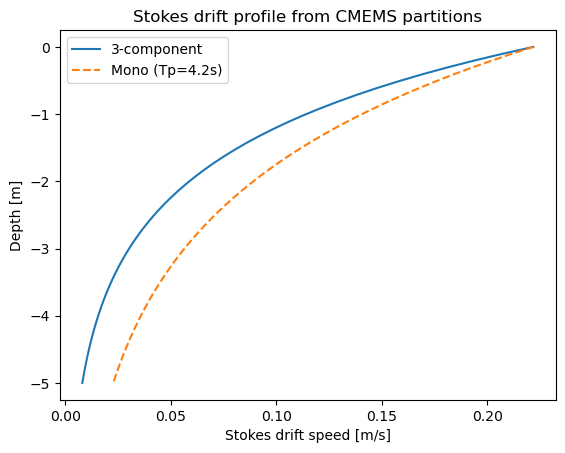

In [8]:
import copernicusmarine as cm

# Load partitioned wave parameters — spatial median over the region
ds_wav = cm.open_dataset(
    dataset_id="cmems_mod_bal_wav_anfc_PT1H-i",
    service="arco-geo-series",
).sel(
    longitude=slice(9.75, 11.0),
    latitude=slice(54.3, 54.55),
    time=slice("2023-04-25T12:00", "2023-04-25T12:00"),  # single strong-Stokes timestep
)[["VHM0_WW", "VTM01_WW", "VMDR_WW",
   "VHM0_SW1", "VTM01_SW1", "VMDR_SW1",
   "VHM0_SW2", "VTM01_SW2", "VMDR_SW2",
   "VSDX", "VSDY"]].load()

# Spatial median
def med(v):
    return float(ds_wav[v].median())

# 3 wave components: (Hs, T, direction_from in degrees)
components = []
for prefix, name in [("WW", "Wind wave"), ("SW1", "Swell 1"), ("SW2", "Swell 2")]:
    hs_i = med(f"VHM0_{prefix}")
    T_i = med(f"VTM01_{prefix}")
    dir_i = med(f"VMDR_{prefix}")  # direction FROM (meteorological)
    if hs_i > 0.01 and np.isfinite(T_i):
        A_i = hs_i / 2
        sigma_i = 2 * np.pi / T_i
        k_i = sigma_i**2 / g
        # Direction: convert from "coming from" to "going to" in math convention
        theta_i = np.radians(270 - dir_i)  # met → math
        components.append({"name": name, "A": A_i, "sigma": sigma_i, "k": k_i,
                           "dir_x": np.cos(theta_i), "dir_y": np.sin(theta_i),
                           "Hs": hs_i, "T": T_i, "dir_from": dir_i})

for c in components:
    u_St_i = c["A"]**2 * c["sigma"] * c["k"]
    H_e_i = 1 / (2 * c["k"])
    print(f'{c["name"]:12s}: Hs={c["Hs"]:.3f}m  T={c["T"]:.1f}s  dir={c["dir_from"]:.0f}°  '
          f'u_St(0)={u_St_i:.4f} m/s  H_e={H_e_i:.2f}m')

# Total surface Stokes from components
u_St_0_3c = sum(c["A"]**2 * c["sigma"] * c["k"] * c["dir_x"] for c in components)
v_St_0_3c = sum(c["A"]**2 * c["sigma"] * c["k"] * c["dir_y"] for c in components)
print(f'\n3-comp surface Stokes: ({u_St_0_3c:.4f}, {v_St_0_3c:.4f}) m/s, '
      f'|u_St|={np.sqrt(u_St_0_3c**2 + v_St_0_3c**2):.4f} m/s')
print(f'CMEMS surface Stokes:  ({med("VSDX"):.4f}, {med("VSDY"):.4f}) m/s')

# Stokes profile
z_prof = np.linspace(0, 5, 50)
u_St_prof = np.array([sum(c["A"]**2 * c["sigma"] * c["k"] * np.exp(-2*c["k"]*z) * c["dir_x"]
                          for c in components) for z in z_prof])
v_St_prof = np.array([sum(c["A"]**2 * c["sigma"] * c["k"] * np.exp(-2*c["k"]*z) * c["dir_y"]
                          for c in components) for z in z_prof])
speed_St_prof = np.sqrt(u_St_prof**2 + v_St_prof**2)

fig, ax = plt.subplots()
ax.plot(speed_St_prof, -z_prof, label="3-component")
ax.plot(speed_St_prof[0] * np.exp(-2*k*z_prof), -z_prof, "--", label=f"Mono (Tp={Tp}s)")
ax.set_xlabel("Stokes drift speed [m/s]")
ax.set_ylabel("Depth [m]")
ax.set_title("Stokes drift profile from CMEMS partitions")
ax.legend()
plt.show()

## Wave orbital velocity field (3-component)

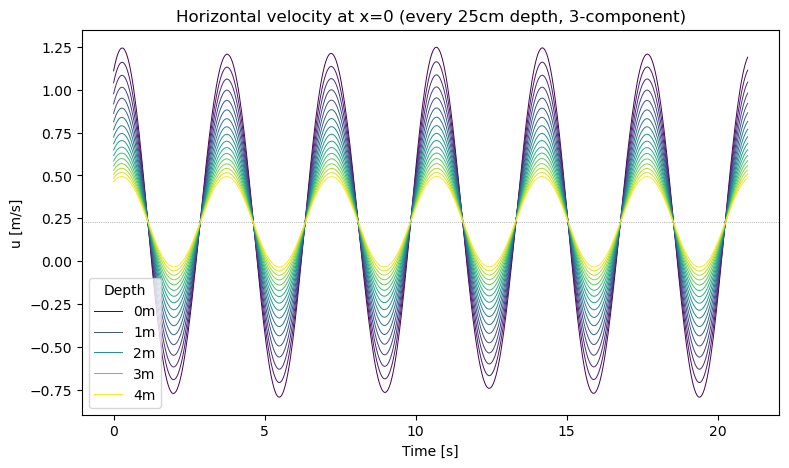

In [9]:
# Random phases for each component
np.random.seed(7)
for c in components:
    c["phase"] = np.random.uniform(0, 2 * np.pi)

def wave_3c_u(x, z, t):
    """Eastward velocity from 3-component wave + mean current."""
    u = U_mean
    for c in components:
        u += c["A"] * c["sigma"] * np.exp(-c["k"] * z) * np.cos(c["k"] * x - c["sigma"] * t + c["phase"]) * c["dir_x"]
    return u

# Velocity profiles at every 25cm depth
t_show = np.linspace(0, 5 * Tp, 500)
depths = np.arange(0, 4.25, 0.25)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(depths)))
for i, z in enumerate(depths):
    u_t = np.array([wave_3c_u(0, z, ti) for ti in t_show])
    ax.plot(t_show, u_t, color=colors[i], linewidth=0.7,
            label=f"{z:.0f}m" if z % 1 == 0 else None)

ax.set_xlabel("Time [s]")
ax.set_ylabel("u [m/s]")
ax.set_title("Horizontal velocity at x=0 (every 25cm depth, 3-component)")
ax.legend(title="Depth")
ax.axhline(U_mean, color="tab:gray", linestyle=":", linewidth=0.5)
plt.show()

## Drifter in 3-component waves vs Stokes profile

In [10]:
def wave_3c_uv(*, t, z_d, y_b, x_b):
    """3-component wave orbital velocity + background current."""
    U_b, V_b = U_mean, 0.0
    U_d, V_d = U_mean, 0.0
    for c in components:
        phase_b = c["k"] * x_b - c["sigma"] * t + c["phase"]
        phase_d = c["k"] * x_b - c["sigma"] * t + c["phase"]  # x_d ≈ x_b
        U_b += c["A"] * c["sigma"] * np.cos(phase_b) * c["dir_x"]
        V_b += c["A"] * c["sigma"] * np.cos(phase_b) * c["dir_y"]
        U_d += c["A"] * c["sigma"] * np.exp(-c["k"] * z_d) * np.cos(phase_d) * c["dir_x"]
        V_d += c["A"] * c["sigma"] * np.exp(-c["k"] * z_d) * np.cos(phase_d) * c["dir_y"]
    return U_b, V_b, U_d, V_d

def stokes_3c_uv(*, t, z_d, y_b, x_b):
    """3-component Stokes drift profile + background current (steady)."""
    U_b = U_mean + sum(c["A"]**2 * c["sigma"] * c["k"] * c["dir_x"] for c in components)
    V_b = sum(c["A"]**2 * c["sigma"] * c["k"] * c["dir_y"] for c in components)
    U_d = U_mean + sum(c["A"]**2 * c["sigma"] * c["k"] * np.exp(-2*c["k"]*z_d) * c["dir_x"] for c in components)
    V_d = sum(c["A"]**2 * c["sigma"] * c["k"] * np.exp(-2*c["k"]*z_d) * c["dir_y"] for c in components)
    return U_b, V_b, U_d, V_d

dd_3c = DroguedDrifter(get_uv=wave_3c_uv)
ds_j = dd_3c.get_full_solution(t_span=(0, T_total), t_eval=t_eval, atol=1e-6, rtol=1e-6)

dd_3c_stokes = DroguedDrifter(get_uv=stokes_3c_uv)
ds_js = dd_3c_stokes.get_full_solution(t_span=(0, T_total), t_eval=t_eval)

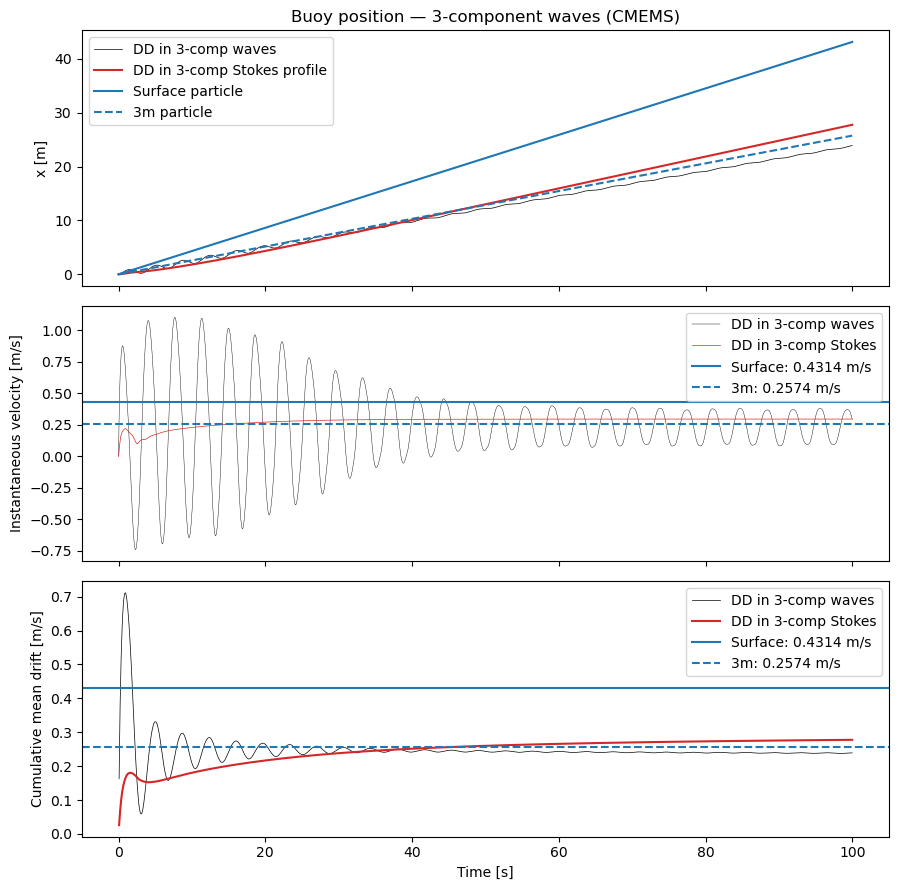

In [11]:
x_j_wave = ds_j.x.values
x_j_stokes = ds_js.x.values

u_surf_3c = U_mean + u_St_0_3c
u_3m_3c = U_mean + sum(c["A"]**2 * c["sigma"] * c["k"] * np.exp(-2*c["k"]*3) * c["dir_x"] for c in components)
x_surf_3c = u_surf_3c * t_eval
x_3m_3c = u_3m_3c * t_eval

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

ax1.plot(t_eval, x_j_wave, "k", linewidth=0.5, label="DD in 3-comp waves")
ax1.plot(t_eval, x_j_stokes, color="tab:red", label="DD in 3-comp Stokes profile")
ax1.plot(t_eval, x_surf_3c, color="tab:blue", linestyle="-", label="Surface particle")
ax1.plot(t_eval, x_3m_3c, color="tab:blue", linestyle="--", label="3m particle")
ax1.set_ylabel("x [m]")
ax1.legend()
ax1.set_title("Buoy position — 3-component waves (CMEMS)")

ax2.plot(t_eval, ds_j.xd.values, "k", linewidth=0.3, label="DD in 3-comp waves")
ax2.plot(t_eval, ds_js.xd.values, color="tab:red", linewidth=0.5, label="DD in 3-comp Stokes")
ax2.axhline(u_surf_3c, color="tab:blue", linestyle="-", label=f"Surface: {u_surf_3c:.4f} m/s")
ax2.axhline(u_3m_3c, color="tab:blue", linestyle="--", label=f"3m: {u_3m_3c:.4f} m/s")
ax2.set_ylabel("Instantaneous velocity [m/s]")
ax2.legend()

t_nz = t_eval[1:]
ax3.plot(t_nz, x_j_wave[1:] / t_nz, "k", linewidth=0.5, label="DD in 3-comp waves")
ax3.plot(t_nz, x_j_stokes[1:] / t_nz, color="tab:red", label="DD in 3-comp Stokes")
ax3.axhline(u_surf_3c, color="tab:blue", linestyle="-", label=f"Surface: {u_surf_3c:.4f} m/s")
ax3.axhline(u_3m_3c, color="tab:blue", linestyle="--", label=f"3m: {u_3m_3c:.4f} m/s")
ax3.set_ylabel("Cumulative mean drift [m/s]")
ax3.set_xlabel("Time [s]")
ax3.legend()

plt.tight_layout()
plt.show()

## Comparison: monochromatic vs 3-component

In [12]:
t_last = t_eval > T_total / 2

def _md(x_arr):
    return (x_arr[t_last][-1] - x_arr[t_last][0]) / (t_eval[t_last][-1] - t_eval[t_last][0])

print(f"Mean drift velocities (last {T_total/2:.0f}s):")
print(f"{'':>35s} {'Mono':>10s} {'3-comp':>10s}")
print(f"{'DD in waves (orbital)':>35s} {mean_drift(x_wave):10.5f} {_md(x_j_wave):10.5f}")
print(f"{'DD in Stokes profile':>35s} {mean_drift(x_stokes):10.5f} {_md(x_j_stokes):10.5f}")
print(f"{'Surface particle':>35s} {U_mean + u_St_0:10.5f} {u_surf_3c:10.5f}")
print(f"{'3m particle':>35s} {U_mean + u_St_3:10.5f} {u_3m_3c:10.5f}")
print(f"{'Waves − Stokes DD':>35s} {(mean_drift(x_wave)-mean_drift(x_stokes))*1000:9.2f}  {(_md(x_j_wave)-_md(x_j_stokes))*1000:9.2f} mm/s")

# Multi-seed for 3-component
n_seeds = 10
drifts_3c = []
for seed in range(n_seeds):
    phases = {c["name"]: np.random.RandomState(seed).uniform(0, 2*np.pi) for c in components}
    comps_trial = [dict(c, phase=phases[c["name"]]) for c in components]

    def _uv(*, t, z_d, y_b, x_b, _comps=comps_trial):
        Ub, Vb, Ud, Vd = U_mean, 0.0, U_mean, 0.0
        for c in _comps:
            ph = c["k"]*x_b - c["sigma"]*t + c["phase"]
            Ub += c["A"]*c["sigma"]*np.cos(ph)*c["dir_x"]
            Vb += c["A"]*c["sigma"]*np.cos(ph)*c["dir_y"]
            Ud += c["A"]*c["sigma"]*np.exp(-c["k"]*z_d)*np.cos(ph)*c["dir_x"]
            Vd += c["A"]*c["sigma"]*np.exp(-c["k"]*z_d)*np.cos(ph)*c["dir_y"]
        return Ub, Vb, Ud, Vd

    dd_t = DroguedDrifter(get_uv=_uv)
    ds_t = dd_t.get_full_solution(t_span=(0, T_total), t_eval=t_eval, atol=1e-6, rtol=1e-6)
    drifts_3c.append(_md(ds_t.x.values))

drifts_3c = np.array(drifts_3c)
u_stokes_3c = _md(x_j_stokes)
print(f"\n3-comp DD in waves ({n_seeds} seeds):")
print(f"  Mean:  {drifts_3c.mean():.5f} ± {drifts_3c.std():.5f} m/s")
print(f"  Stokes DD: {u_stokes_3c:.5f} m/s")
print(f"  Diff:  {(drifts_3c.mean() - u_stokes_3c)*1000:.2f} ± {drifts_3c.std()*1000:.2f} mm/s")

Mean drift velocities (last 50s):
                                          Mono     3-comp
              DD in waves (orbital)    0.24378    0.23496
               DD in Stokes profile    0.30840    0.29524
                   Surface particle    0.42000    0.43142
                        3m particle    0.27834    0.25742
                  Waves − Stokes DD    -64.62     -60.28 mm/s



3-comp DD in waves (10 seeds):
  Mean:  0.23320 ± 0.00289 m/s
  Stokes DD: 0.29524 m/s
  Diff:  -62.04 ± 2.89 mm/s
